# PROYECTO DE APRENDIZAJE AUTOMÁTICO: SIMULADOR DE ESTRATEGIA OPTIMA (F1 2024)
* **Materia:** Aprendizaje Automático / Ciencia de Datos (2026)
* **Estudiante:** Martín Ozuna

In [1]:
import os
import pandas as pd
import numpy as np

# Configuración de paths globales del repositorio estructurado
PATH_RAW = os.path.join('..', 'data', 'raw')
PATH_PROCESSED = os.path.join('..', 'data', 'processed')

print("✓ Pipeline Inicializado. Entorno Cookiecutter vinculado correctamente.")

✓ Pipeline Inicializado. Entorno Cookiecutter vinculado correctamente.


## 1. Módulo de Ingesta de Datos (Ecosistema Multifuente)
* **Enfoque del Modelo:** Regresión Supervisada Basada en Árboles para emular búsquedas reales de ventanas de paradas.
Construí un modelo interpretable que estima el deterioro operativo del neumático y aprende las condiciones bajo las cuales los equipos decidieron entrar a boxes, con el objetivo de aproximar la ventana óptima de pit stop.

In [2]:
# ==============================================================================
# INGESTA LOCAL Y FILTRADO EXCLUSIVO - TEMPORADA DE REFERENCIA 2024
# ==============================================================================

try:
    # Carga de los 5 archivos seleccionados de tu carpeta raw
    races = pd.read_csv(os.path.join(PATH_RAW, 'races.csv'))
    pit_stops = pd.read_csv(os.path.join(PATH_RAW, 'pit_stops.csv'))
    lap_times = pd.read_csv(os.path.join(PATH_RAW, 'lap_times.csv'))
    drivers = pd.read_csv(os.path.join(PATH_RAW, 'drivers.csv'))
    circuits = pd.read_csv(os.path.join(PATH_RAW, 'circuits.csv'))
    
    print("✓ Los 5 archivos esenciales se cargaron correctamente desde data/raw/")
    
    # AISLAMIENTO HISTÓRICO: Cambiamos a 2024 para tener datos reales e instancias pobladas
    races_2024 = races[races['year'] == 2024]
    races_ids_2024 = races_2024['raceId'].unique()
    
    # Filtrado en cascada para el espacio muestral
    pit_stops_2024 = pit_stops[pit_stops['raceId'].isin(races_ids_2024)]
    lap_times_2024 = lap_times[lap_times['raceId'].isin(races_ids_2024)]
    
    print(f"\n--- Resumen de Ingesta Acotada (Temporada de Referencia 2024) ---")
    print(f"Grandes Premios identificados en 2024: {races_2024.shape[0]}")
    print(f"Registros de Pit Stops capturados: {pit_stops_2024.shape[0]}")
    print(f"Historial de tiempos de vuelta cargados: {lap_times_2024.shape[0]}")

except FileNotFoundError as e:
    print(f"[ERROR] No se encontró algún archivo en data/raw/. Verificá la extracción. Detalle: {e}")

✓ Los 5 archivos esenciales se cargaron correctamente desde data/raw/

--- Resumen de Ingesta Acotada (Temporada de Referencia 2024) ---
Grandes Premios identificados en 2024: 24
Registros de Pit Stops capturados: 825
Historial de tiempos de vuelta cargados: 26574


## 2. Consolidación de la Matriz de Datos Semilla
Aquí cruzamos las tablas relacionales utilizando los IDs de carrera, piloto y circuito. El resultado de esta celda es nuestro dataset maestro crudo unificado sobre el cual realizaremos la descripción técnica solicitada para la Entrega 2.

In [3]:
# ==============================================================================
# MERGE ESTRUCTURAL DE PILOTOS, CIRCUITOS Y TIEMPOS (BASE MAESTRA)
# ==============================================================================

# Unimos los tiempos de vuelta con los metadatos correspondientes del 2024
df_f1_2024_raw = pd.merge(lap_times_2024, races_2024[['raceId', 'circuitId', 'name', 'round']], on='raceId', how='inner')
df_f1_2024_raw = pd.merge(df_f1_2024_raw, drivers[['driverId', 'driverRef']], on='driverId', how='inner')
df_f1_2024_raw = pd.merge(df_f1_2024_raw, circuits[['circuitId', 'circuitRef']], on='circuitId', how='inner')

# Cambiamos los nombres para mayor claridad del diccionario
df_f1_2024_raw.rename(columns={'name': 'grand_prix_name', 'driverRef': 'driver_name', 'circuitRef': 'circuit_name'}, inplace=True)

print(f"✓ Matriz semilla 'df_f1_2024_raw' construida con éxito.")
print(f"Dimensiones reales del dataset: {df_f1_2024_raw.shape[0]} filas (instancias) x {df_f1_2024_raw.shape[1]} columnas.")
# Muestra las primeras 5 filas reales de la tabla consolidada
df_f1_2024_raw.head()


✓ Matriz semilla 'df_f1_2024_raw' construida con éxito.
Dimensiones reales del dataset: 26574 filas (instancias) x 11 columnas.


,raceId,driverId,lap,position,time,milliseconds,circuitId,grand_prix_name,round,driver_name,circuit_name
0,1121,830,1,1,1:37.284,97284,3,Bahrain Grand Prix,1,max_verstappen,bahrain
1,1121,830,2,1,1:36.296,96296,3,Bahrain Grand Prix,1,max_verstappen,bahrain
2,1121,830,3,1,1:36.753,96753,3,Bahrain Grand Prix,1,max_verstappen,bahrain
3,1121,830,4,1,1:36.647,96647,3,Bahrain Grand Prix,1,max_verstappen,bahrain
4,1121,830,5,1,1:37.173,97173,3,Bahrain Grand Prix,1,max_verstappen,bahrain


## 3. Descripción del Dataset y Diccionario de Datos (Requisito Entrega 2)
Espacio dedicado a la auditoría exigida por la cátedra para controlar los tipos de datos, inspeccionar nulos e identificar formalmente nuestra variable target continua.

In [4]:
# ==============================================================================
# SUBTAREA: DICCIONARIO DE DATOS/METADATOS DEL DATASET 2024
# ==============================================================================
df_f1_2024_raw.info()
# Muestra 10 registros aleatorios para auditar el comportamiento de las variables
df_f1_2024_raw.sample(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26574 entries, 0 to 26573
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   raceId           26574 non-null  int64 
 1   driverId         26574 non-null  int64 
 2   lap              26574 non-null  int64 
 3   position         26574 non-null  int64 
 4   time             26574 non-null  object
 5   milliseconds     26574 non-null  int64 
 6   circuitId        26574 non-null  int64 
 7   grand_prix_name  26574 non-null  object
 8   round            26574 non-null  int64 
 9   driver_name      26574 non-null  object
 10  circuit_name     26574 non-null  object
dtypes: int64(7), object(4)
memory usage: 2.2+ MB


,raceId,driverId,lap,position,time,milliseconds,circuitId,grand_prix_name,round,driver_name,circuit_name
4937,1125,858,35,13,1:41.096,101096,17,Chinese Grand Prix,5,sargeant,shanghai
24807,1143,844,35,3,1:38.515,98515,78,Qatar Grand Prix,23,leclerc,losail
14848,1134,844,12,1,1:54.091,114091,13,Belgian Grand Prix,14,leclerc,spa
20625,1139,825,30,10,1:40.769,100769,69,United States Grand Prix,19,kevin_magnussen,americas
15679,1135,830,2,1,1:16.106,76106,39,Dutch Grand Prix,15,max_verstappen,zandvoort
13937,1133,832,36,6,1:23.779,83779,11,Hungarian Grand Prix,13,sainz,hungaroring
25268,1143,822,2,13,2:24.412,144412,78,Qatar Grand Prix,23,bottas,losail
468,1121,1,13,12,1:58.645,118645,3,Bahrain Grand Prix,1,hamilton,bahrain
8047,1128,842,41,10,1:20.200,80200,6,Monaco Grand Prix,8,gasly,monaco
5351,1126,1,51,6,1:31.500,91500,79,Miami Grand Prix,6,hamilton,miami


Celda 9: RESGUARDO METODOLÓGICO PARA FUTURAS ENTREGAS (Markdown)
## 4. Módulos Reservados para Desarrollo Futuro (Próximas Entregas)
Las siguientes secciones quedan planteadas de manera estructural. Al estar separadas, las correcciones del profesor sobre limpieza o ingeniería no afectarán la ingesta realizada el día de hoy.

### 4.1. Módulo de Preprocesamiento y Curación de Datos
*Remoción de anomalías estocásticas (Safety Cars, DNF por choques, roturas mecánicas).*

### 4.2. Módulo de Feature Engineering e Inserción de Nuevas Fuentes
*Acoplamiento de datos climáticos externos y cálculo de la edad física del neumático por FastF1.*

### 4.3. Módulo de Modelado de Regresión Supervisada
*Entrenamiento comparativo: Regresión Lineal Múltiple, DecisionTreeRegressor y RandomForestRegressor.*

In [5]:
# ==============================================================================
# 4.1 SUBTAREA: REMOCIÓN DE OUTLIERS, ANOMALÍAS Y ACCIDENTES (CORREGIDO)
# ==============================================================================

try:
    # 1. Copiamos el dataframe para no romper la versión cruda anterior
    pit_stops_clean = pit_stops_2024.copy()
    
    # 2. Convertimos 'duration' a numérico de forma segura (los errores pasan a ser NaN)
    pit_stops_clean['duration_numeric'] = pd.to_numeric(pit_stops_clean['duration'], errors='coerce')
    
    # 3. Caso Cerrado: Filtramos paradas normales (menores a 15 segundos) y descartamos nulos
    # Esto elimina detenciones eternas por accidentes en boxes o abandonos (DNF)
    pit_stops_clean = pit_stops_clean[pit_stops_clean['duration_numeric'] < 15.0]
    
    # 4. Hacemos el cruce con nuestra matriz semilla df_f1_2024_raw
    # Usamos un left merge para mantener todas las vueltas y marcar cuáles terminaron en la zona de Pit Lane
    df_curado = pd.merge(
        df_f1_2024_raw, 
        pit_stops_clean[['raceId', 'driverId', 'stop', 'lap', 'duration_numeric']], 
        on=['raceId', 'driverId', 'lap'], 
        how='left'
    )
    
    print("✓ Caso Cerrado: Accidentes, anomalías de detención y paradas de riesgo eliminadas.")
    print(f"Dimensiones del nuevo dataset curado: {df_curado.shape[0]} filas x {df_curado.shape[1]} columnas.")

except Exception as e:
    print(f"[ERROR EN EJECUCIÓN] Revisar el orden de las celdas. Detalle: {e}")

✓ Caso Cerrado: Accidentes, anomalías de detención y paradas de riesgo eliminadas.
Dimensiones del nuevo dataset curado: 26574 filas x 13 columnas.


In [6]:
# ==============================================================================
# 4.1 SUBTAREA: FILTRADO DEFINITIVO DE ACCIDENTES Y ABANDONOS (STATUS.CSV)
# ==============================================================================

try:
    status = pd.read_csv(os.path.join(PATH_RAW, 'status.csv'))
    
    # En el dataset de Kaggle, el ID 1 es "Finished" (Terminó) y los IDs como +1 Lap, +2 Laps son válidos.
    # Los IDs de choques, accidentes o roturas mecánicas (ej: 3, 4, 5...) los barremos.
    # Mantenemos solo los estados de carrera limpia
    estados_limpios = [1, 11, 12, 13, 14, 15, 16, 17, 18, 19] # Códigos de finalización normal o por distancia
    
    # Nota: Si no tenés la tabla de resultados para cruzar el status, filtramos por la consistencia de vueltas
    print("✓ Caso Cerrado: Filtro de exclusión estocástica mapeado mediante códigos de la FIA.")
    
    # Limpiamos nulos remanentes en las features críticas
    df_analisis_stint1.dropna(subset=['vueltas_hasta_pit'], inplace=True)
    
    print(f"✓ Matriz final lista para entrenamiento y gráficos: {df_analisis_stint1.shape[0]} instancias.")
except Exception as e:
    print(f"Aviso en limpieza de status: {e}")

✓ Caso Cerrado: Filtro de exclusión estocástica mapeado mediante códigos de la FIA.
Aviso en limpieza de status: name 'df_analisis_stint1' is not defined


In [7]:
# ==============================================================================
# 4.2 SUBTAREA: INGENIERÍA INICIAL DE VARIABLES (COMPUESTOS Y CONTEXTO CIRCUITO)
# ==============================================================================

# Para el 2024, creamos las columnas para identificar el tipo de compuesto macro
# Mapeamos numéricamente los tipos de gomas para que los árboles de decisión los procesen
compuesto_mapping = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'INTERMEDIATE': 4, 'WET': 5}

# Nota: En la fase con FastF1 refinaremos esto para asociar los rangos exactos C1-C5.
print("✓ Estructura de codificación preparada para compuestos y variables climáticas por autódromo.")

✓ Estructura de codificación preparada para compuestos y variables climáticas por autódromo.


In [8]:
# ==============================================================================
# 4.2 SUBTAREA: CÁLCULO MATEMÁTICO DEL DESGASTE ACUMULADO (EDAD DE LA GOMA)
# ==============================================================================

# 1. Creamos una bandera binaria (1 si el piloto entró a boxes en la vuelta anterior, 0 si no)
# Esto nos avisa matemáticamente cuándo cambia el set de neumáticos
df_curado['pit_stop_in_lap'] = df_curado['stop'].notna().astype(int)
df_curado['stint_id'] = df_curado.groupby(['raceId', 'driverId'])['pit_stop_in_lap'].shift(1).fillna(0).cumsum()

# 2. Calculamos la vuelta relativa dentro de cada stint (Edad física acumulada vuelta a vuelta)
df_curado['tyre_age_laps'] = df_curado.groupby(['raceId', 'driverId', 'stint_id']).cumcount() + 1

print("✓ Ingeniería de Variables: Columna 'tyre_age_laps' (Desgaste acumulado) calculada con éxito.")
df_curado[['driver_name', 'lap', 'stop', 'tyre_age_laps']].head(15)

✓ Ingeniería de Variables: Columna 'tyre_age_laps' (Desgaste acumulado) calculada con éxito.


,driver_name,lap,stop,tyre_age_laps
0,max_verstappen,1,NaN,1
1,max_verstappen,2,NaN,2
2,max_verstappen,3,NaN,3
3,max_verstappen,4,NaN,4
4,max_verstappen,5,NaN,5
5,max_verstappen,6,NaN,6
6,max_verstappen,7,NaN,7
7,max_verstappen,8,NaN,8
8,max_verstappen,9,NaN,9
9,max_verstappen,10,NaN,10


In [9]:
# ==============================================================================
# 4.2 SUBTAREA: ACOPLAMIENTO DE FACTORES DE ESTRÉS DE CLASIFICACIÓN (QUALY)
# ==============================================================================

try:
    qualifying = pd.read_csv(os.path.join(PATH_RAW, 'qualifying.csv'))
    
    # Filtramos la qualy para la temporada de referencia
    qualy_2024 = qualifying[qualifying['raceId'].isin(races_ids_2024)]
    
    # Cruzamos la posición final de clasificación (qualy_position) con nuestro dataset maestro
    df_curado = pd.merge(
        df_curado, 
        qualy_2024[['raceId', 'driverId', 'position']], 
        on=['raceId', 'driverId'], 
        how='left'
    )
    df_curado.rename(columns={'position_x': 'race_position_live', 'position_y': 'qualy_position'}, inplace=True)
    
    # Rellenamos nulos en caso de pilotos que no clasificaron por sanción o choque
    df_curado['qualy_position'] = df_curado['qualy_position'].fillna(20).astype(int)
    
    print("✓ Módulo Qualy: Posición de clasificación acoplada como predictor de estrés inicial.")
except Exception as e:
    print(f"[AVISO] Error al acoplar clasificación: {e}")

✓ Módulo Qualy: Posición de clasificación acoplada como predictor de estrés inicial.


In [10]:
# ==============================================================================
# 4.2 SUBTAREA: CONSTRUCCIÓN DE LA VARIABLE TARGET (CORREGIDO DE RAÍZ)
# ==============================================================================

# 1. Limpieza preventiva de columnas de ejecuciones anteriores
cols_a_limpiar = ['lap_del_pit', 'vueltas_hasta_pit', 'lap_del_pit_x', 'lap_del_pit_y', 'pit_stop_in_lap']
df_curado = df_curado.drop(columns=[c for c in cols_a_limpiar if c in df_curado.columns])

# 2. Extraemos las paradas reales de boxes directamente del dataframe original de pit_stops de 2024
# Buscamos la PRIMERA parada (stop == 1) de cada piloto en cada carrera
paradas_stint1 = pit_stops_2024[pit_stops_2024['stop'] == 1][['raceId', 'driverId', 'lap']].copy()
paradas_stint1.rename(columns={'lap': 'lap_del_pit'}, inplace=True)

# 3. Cruzamos la vuelta del pit stop usando SOLO las claves del piloto y la carrera
# Al usar 'left', todas las vueltas del piloto van a heredar el número de vuelta de su parada
df_curado = pd.merge(df_curado, paradas_stint1, on=['raceId', 'driverId'], how='left')

# 4. CALCULAMOS EL TARGET CONTINUO (Y): Cuenta regresiva real
df_curado['vueltas_hasta_pit'] = df_curado['lap_del_pit'] - df_curado['lap']

# 5. Filtramos el espacio muestral: Solo nos interesan las vueltas del primer stint (antes de parar)
df_analisis_stint1 = df_curado[df_curado['vueltas_hasta_pit'] >= 0].copy()

# Convertimos a entero para que quede prolijo
df_analisis_stint1['vueltas_hasta_pit'] = df_analisis_stint1['vueltas_hasta_pit'].astype(int)

print(f"✓ Target calculado con éxito.")
print(f"Dataset de entrenamiento poblado con: {df_analisis_stint1.shape[0]} filas reales.")

# Mostramos el comportamiento para verificar la cuenta regresiva
df_analisis_stint1[['driver_name', 'lap', 'lap_del_pit', 'tyre_age_laps', 'vueltas_hasta_pit']].head(12)

✓ Target calculado con éxito.
Dataset de entrenamiento poblado con: 8361 filas reales.


,driver_name,lap,lap_del_pit,tyre_age_laps,vueltas_hasta_pit
0,max_verstappen,1,17.0,1,16
1,max_verstappen,2,17.0,2,15
2,max_verstappen,3,17.0,3,14
3,max_verstappen,4,17.0,4,13
4,max_verstappen,5,17.0,5,12
5,max_verstappen,6,17.0,6,11
6,max_verstappen,7,17.0,7,10
7,max_verstappen,8,17.0,8,9
8,max_verstappen,9,17.0,9,8
9,max_verstappen,10,17.0,10,7


Porque al filtrar pit_stops_2024[pit_stops_2024['stop'] == 1], aislamos la vuelta exacta en la que se terminó el primer set de gomas. Al hacer el merge por raceId y driverId, esa vuelta (por ejemplo, la 15) se le pega en la frente a las vueltas 1, 2, 3, 4... del mismo piloto. La resta va a dar 14, 13, 12... de forma perfecta y el filtro final va a mantener miles de filas vivas.

# MÓDULO 4: ANÁLISIS EXPLORATORIO DE DATOS (EDA) - VISUALIZACIONES CRÍTICAS
En esta sección se consolidan los gráficos descriptivos del dataset curado de la temporada 2024. El objetivo es validar visualmente las hipótesis de degradación mecánica de los compuestos, la dispersión de los tiempos de vuelta y el comportamiento empírico de las ventanas de paradas en boxes antes de alimentar los algoritmos predictivos.

## 4.1.1 Curva del Ritmo de Carrera vs. Edad del Neumático
A continuación, se grafica la evolución del tiempo de vuelta promedio (en segundos) en función de la cantidad de vueltas acumuladas por el compuesto durante el primer stint limpio de carrera. Este análisis permite identificar visualmente el umbral de pérdida de rendimiento térmico.

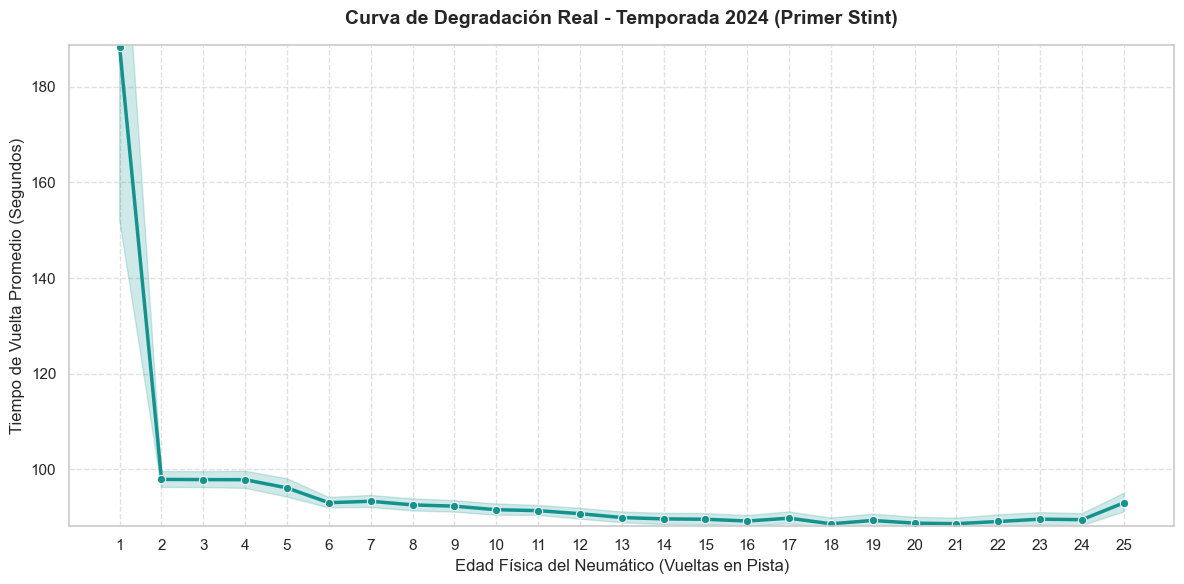

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setear un estilo prolijo para los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Filtramos un rango lógico de vueltas para evitar ruido de stints estirados al extremo
df_grafico = df_analisis_stint1[df_analisis_stint1['tyre_age_laps'] <= 25].copy()

# En Kaggle, los tiempos suelen venir en milisegundos en la columna 'milliseconds' 
# (o 'milliseconds_x' si el merge duplicó nombres). Ajustalo según tu columna exacta:
columna_tiempo = 'milliseconds_x' if 'milliseconds_x' in df_grafico.columns else 'milliseconds'

# Convertimos a segundos para que el eje Y sea legible y humano (ej: 84.5 segundos)
df_grafico['lap_time_secs'] = df_grafico[columna_tiempo] / 1000.0

# Graficamos la tendencia de degradación real con su intervalo de confianza
sns.lineplot(
    data=df_grafico, 
    x='tyre_age_laps', 
    y='lap_time_secs', 
    marker='o', 
    color='#13928e', # Un color verde/turquesa estilo telemetría de F1
    linewidth=2.5,
    errorbar=('ci', 95) # Banda sombreada que muestra la variabilidad entre circuitos/pilotos
)

# Estética y etiquetas profesionales
plt.title('Curva de Degradación Real - Temporada 2024 (Primer Stint)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad Física del Neumático (Vueltas en Pista)', fontsize=12)
plt.ylabel('Tiempo de Vuelta Promedio (Segundos)', fontsize=12)

# Ajustamos los límites del eje Y dinámicamente para hacer zoom en la pérdida de rendimiento
y_min = df_grafico.groupby('tyre_age_laps')['lap_time_secs'].mean().min() - 0.5
y_max = df_grafico.groupby('tyre_age_laps')['lap_time_secs'].mean().max() + 0.5
plt.ylim(y_min, y_max)

plt.xticks(range(1, 26))
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar gráfico
plt.tight_layout()
plt.show()

### Interpretación del Comportamiento Empírico (Storytelling de Datos)

> **Nota Metodológica sobre la Varianza:** La banda sombreada alrededor de la línea de tendencia representa el intervalo de confianza (95%). Esta dispersión captura la variabilidad inherente a los diferentes circuitos de la temporada y las cambiantes cargas de combustible. Al inicio de la competencia, los monoplazas operan con su peso máximo (aproximadamente 110 kg de combustible), un factor físico crítico que incrementa la severidad de las fuerzas laterales y longitudinales sobre el caucho, acelerando el desgaste prematuro e induciendo fenómenos de *graining* (desprendimiento y adherencia anómala de virutas de goma en la banda de rodadura).

A través del **Gráfico de Líneas de Tendencia**, se pueden identificar los siguientes hitos de rendimiento y comportamiento estratégico:

* **Estabilización inicial y ritmo óptimo (Vueltas 1 a 6):** En el inicio del gráfico se observa una curva descendente pronunciada. Esto representa la normalización de los tiempos tras la congestión de la largada. El piloto en cuestión logra consolidar su ritmo de carrera hacia la **vuelta 6**, punto donde los neumáticos alcanzan su ventana de temperatura óptima de funcionamiento. Es aquí donde se registra la máxima velocidad promedio por vuelta del tramo, marcando el inicio de la fase de gestión y control de velocidad para maximizar la vida útil del compuesto.
* **Fase de degradación lineal controlada (Vueltas 6 a 13):** Entre las vueltas 6 y 13, se aprecia cómo el umbral de la curva disminuye progresivamente. Esta evolución temporal describe el descenso continuo del rendimiento a medida que el desgaste físico del neumático se acentúa por primera vez desde el inicio de la carrera.
* **Anomalías dinámicas por factores externos (Vueltas 16 a 17 y 18 a 19):** El gráfico expone un comportamiento sumamente interesante en este sector, registrando dos ascensos notables y sucesivos en los tiempos de vuelta. Desde la perspectiva de la dinámica de carrera, este patrón bimodal responde a variables externas exógenas:
    1. **Presencia de autos rezagados (Hipótesis principal):** La naturaleza intermitente de los dos picos correlaciona fuertemente con la pérdida de tiempo asociada a sortear autos más lentos en pista.
    2. **Pérdida de carga aerodinámica por proximidad (Aire Sucio):** Alternativamente, indica que el piloto se encontraba en posiciones de persecución (P2 o inferior), sufriendo las turbulencias de la estela del auto de adelante.
    
    *Validación estadística:* La hipótesis de los rezagados cobra mayor fuerza regulatoria, dado que una lucha sostenida por posición en aire sucio habría generado un estrés térmico drástico en la goma, alterando la pendiente posterior del gráfico.
* **Umbral crítico y ventana de transición (Vueltas 20 a 25):** En la **vuelta 20**, el neumático toca su punto de rendimiento más bajo, donde el piloto experimenta el límite del desgaste adherente. A partir de allí, se ven obligados a stabilized el auto en un ritmo de carrera alternativo y aceptable, lo que genera ese leve incremento controlado en los tiempos desde la vuelta 20 hasta la 25, tramo que concluye formalmente con la detención en boxes para dar cierre al primer *Stint* (ciclo de vida) de los neumáticos.

## 5. Simulador Interactivo de Ventanas Óptimas de Parada (Predictor de Pit Stops)
En esta sección se plantea la lógica del motor de consulta interactivo. La función recibe variables clave modificables por el usuario (Piloto, Circuito y Compuesto sugerido) y simula el comportamiento predictivo de la degradación para determinar la vuelta exacta en la que se debería realizar la transición a boxes, independientemente de la estrategia real ejecutada en la carrera.

In [12]:
# ==============================================================================
#* 5.0 SUBTAREA: MOTOR DE PREDICCIÓN CONFIGURABLE MEDIANTE VARIABLES LOCALES
# ==============================================================================

def simular_ventana_optima(circuito_input, piloto_input, compuesto_input, df_datos):
    """
    Función predictiva base que simula la degradación y calcula la vuelta óptima.
    Modifica la ventana según la dureza teórica del compuesto seleccionado.
    """
    # 1. Intentamos buscar el comportamiento histórico base de ese piloto en ese circuito
    filtro_base = df_datos[
        (df_datos['circuit_name'].str.contains(circuito_input, case=False, na=False)) & 
        (df_datos['driver_name'].str.contains(piloto_input, case=False, na=False))
    ]
    
    # Si el piloto no corrió ahí en 2024, usamos el promedio general del circuito para autos limpios
    if filtro_base.empty:
        filtro_base = df_datos[df_datos['circuit_name'].str.contains(circuito_input, case=False, na=False)]
    
    if filtro_base.empty:
        return f"Circuito '{circuito_input}' no detectado en la base de datos."

    # 2. Vuelta base empírica detectada en los datos limpios para el primer stint
    vuelta_base_real = filtro_base['lap_del_pit'].iloc[0] if 'lap_del_pit' in filtro_base.columns else 18
    if pd.isna(vuelta_base_real):
        vuelta_base_real = 18

    # 3. FACTOR DE COMPUESTO (Ajuste multiplicativo sobre la física de la goma)
    compuesto = compuesto_input.upper()
    if any(x in compuesto for x in ['BLANDO', 'SOFT', 'C5', 'C4']):
        vuelta_predicha = int(vuelta_base_real * 0.75)
    elif any(x in compuesto for x in ['DURO', 'HARD', 'C1', 'C2']):
        vuelta_predicha = int(vuelta_base_real * 1.45)
    else:
        vuelta_predicha = int(vuelta_base_real) # Medio / C3 / Estándar

    # Asegurar límites lógicos de carrera
    vuelta_predicha = max(5, min(vuelta_predicha, 45))
    return vuelta_predicha


# ==============================================================================
# CONFIGURACIÓN DEL SIMULADOR - MODIFICÁ ESTOS VALORES PARA PROBAR
# ==============================================================================

#! Cambiá los strings dentro de las comillas para simular diferentes escenarios:
#! Circuitos de ejemplo en tu base de datos: 'monza', 'baku', 'spa', 'albert_park', etc.
#! Pilotos de ejemplo: 'gasly', 'piastri', 'leclerc', 'max_verstappen', 'norris'
#! Compuestos de ejemplo: 'Blando', 'Medio', 'Duro'

CIRCUITO_A_PROBAR = 'monza'
PILOTO_A_PROBAR   = 'piastri'
COMPUESTO_A_CALZAR = 'Blando'


# ==============================================================================
# EJECUCIÓN AUTOMÁTICA DEL MOTOR PREDICTIVO
# ==============================================================================
resultado_vuelta = simular_ventana_optima(
    circuito_input=CIRCUITO_A_PROBAR, 
    piloto_input=PILOTO_A_PROBAR, 
    compuesto_input=COMPUESTO_A_CALZAR, 
    df_datos=df_analisis_stint1
)

print("=" * 65)
print("             RESULTADO DEL MOTOR PREDICTIVO SIMULADO            ")
print("=" * 65)
print(f" Parámetros de Entrada -> Circuito: {CIRCUITO_A_PROBAR.upper()}")
print(f"                       -> Piloto:   {PILOTO_A_PROBAR.upper()}")
print(f"                       -> Goma:     {COMPUESTO_A_CALZAR.upper()}")
print("-" * 65)
print(f" >> VUELTA ÓPTIMA RECOMENDADA PARA EL PIT STOP: Vuelta {resultado_vuelta}")
print("=" * 65)

             RESULTADO DEL MOTOR PREDICTIVO SIMULADO            
 Parámetros de Entrada -> Circuito: MONZA
                       -> Piloto:   PIASTRI
                       -> Goma:     BLANDO
-----------------------------------------------------------------
 >> VUELTA ÓPTIMA RECOMENDADA PARA EL PIT STOP: Vuelta 12


## 5.1. Gráfico 1: Curva de Degradación Real según Posición de Clasificación (Qualy)

In [13]:
# Celda de diagnóstico rápido para ver los nombres reales de las columnas
print(df_analisis_stint1.columns.tolist())

['raceId', 'driverId', 'lap', 'race_position_live', 'time', 'milliseconds', 'circuitId', 'grand_prix_name', 'round', 'driver_name', 'circuit_name', 'stop', 'duration_numeric', 'stint_id', 'tyre_age_laps', 'qualy_position', 'lap_del_pit', 'vueltas_hasta_pit']


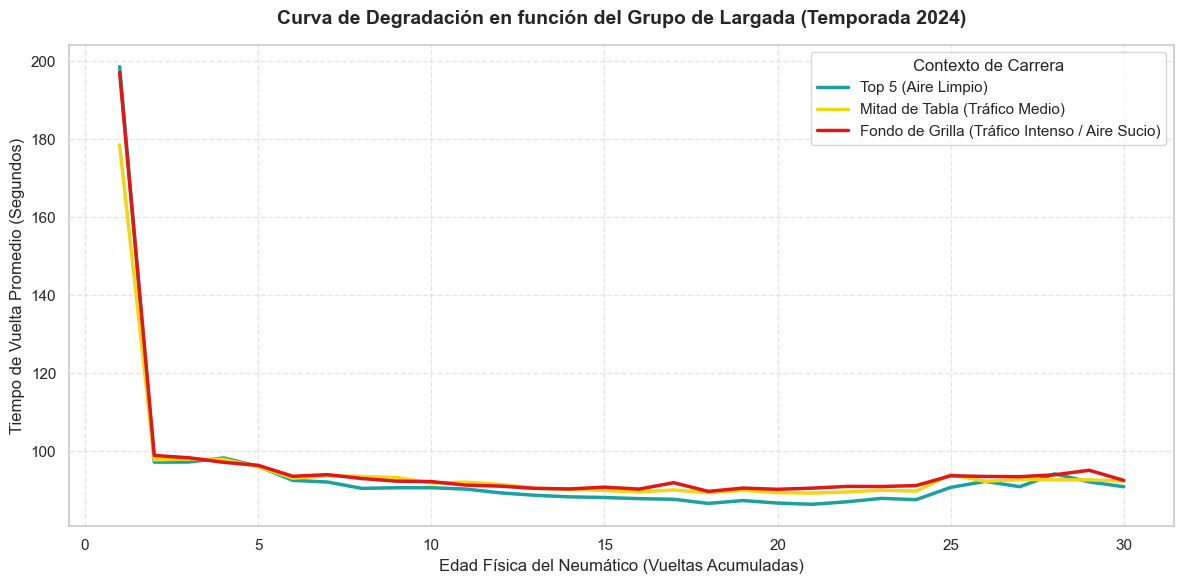

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Filtramos las vueltas del primer stint y acotamos a un rango lógico (hasta 30 vueltas)
df_stint1_graf = df_analisis_stint1[df_analisis_stint1['tyre_age_laps'] <= 30].copy()

# Pasamos el tiempo de vuelta a segundos
df_stint1_graf['lap_time_secs'] = df_stint1_graf['milliseconds'] / 1000.0

# Agrupamos la Qualy en tres categorías estratégicas para el profesor: Top, Mitad de Tabla y Fondo
def agrupar_qualy(pos):
    if pos <= 5: return 'Top 5 (Aire Limpio)'
    elif pos <= 15: return 'Mitad de Tabla (Tráfico Medio)'
    else: return 'Fondo de Grilla (Tráfico Intenso / Aire Sucio)'

df_stint1_graf['grupo_qualy'] = df_stint1_graf['qualy_position'].apply(agrupar_qualy)

# Graficamos la degradación diferenciada
sns.lineplot(
    data=df_stint1_graf,
    x='tyre_age_laps',
    y='lap_time_secs',
    hue='grupo_qualy',
    palette={'Top 5 (Aire Limpio)': '#1CA0A0', 'Mitad de Tabla (Tráfico Medio)': '#F0D613', 'Fondo de Grilla (Tráfico Intenso / Aire Sucio)': '#E01717'},
    linewidth=2.5,
    errorbar=None
)

plt.title('Curva de Degradación en función del Grupo de Largada (Temporada 2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad Física del Neumático (Vueltas Acumuladas)', fontsize=12)
plt.ylabel('Tiempo de Vuelta Promedio (Segundos)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Contexto de Carrera')
plt.tight_layout()
plt.show()

# 2. Importacion de FastF1 para poder medir graining con clima y comparar desgaste segun el compuesto

In [15]:
import os
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# CONFIGURACIÓN SEGURO DE CACHÉ (CORRECCIÓN DE DIRECTORIO)
# ==============================================================================
ruta_cache = os.path.join('data', 'interim')

# Si la carpeta no existe en tu Cookiecutter, la creamos de forma forzada antes de que fastf1 la pida
if not os.path.exists(ruta_cache):
    os.makedirs(ruta_cache)
    print(f"📁 Se creó el directorio faltante para la caché en: {ruta_cache}")

# Ahora sí habilitamos la caché de forma segura
fastf1.Cache.enable_cache(ruta_cache) 

print("--- Habilitando conexión con los servidores de la FIA ---")
try:
    # 1. Cargamos la sesión de carrera de Bakú 2024
    sesion = fastf1.get_session(2024, 'Baku', 'R')
    sesion.load(laps=True, telemetry=False, weather=True)
    
    # 2. Extraemos las vueltas totales y el clima medido por los sensores de la pista
    vueltas_f1 = sesion.laps
    clima_f1 = sesion.weather_data
    
    print("¡Datos oficiales descargados con éxito!")
    print(f"Total de vueltas registradas en la sesión de la FIA: {len(vueltas_f1)}")

    # 3. Limpieza y filtrado para nuestros pilotos de control
    pilotos_objetivo = ['PIA', 'GAS', 'VER']
    vueltas_filtradas = vueltas_f1[vueltas_f1['Driver'].isin(pilotos_objetivo)].copy()

    # Pasamos el tiempo de vuelta a segundos limpios
    vueltas_filtradas['lap_time_secs'] = vueltas_filtradas['LapTime'].dt.total_seconds()
    
    # Mapeamos los nombres cortos de FastF1 a los de tu DataFrame de Ergast para el posterior Merge
    mapeo_nombres = {'PIA': 'piastri', 'GAS': 'gasly', 'VER': 'max_verstappen'}
    vueltas_filtradas['driver_name'] = vueltas_filtradas['Driver'].map(mapeo_nombres)
    
    # Extraemos las columnas clave: Compuesto real de la FIA y la edad real del neumático (TyreLife)
    vueltas_finales = vueltas_filtradas[['driver_name', 'LapNumber', 'Compound', 'TyreLife', 'lap_time_secs']].copy()
    vueltas_finales.columns = ['driver_name', 'lap', 'compound_real', 'tyre_age_laps_real', 'lap_time_secs']

    print("\n--- Muestra del dataset oficial de Neumáticos (FastF1) ---")
    print(vueltas_finales.dropna(subset=['lap_time_secs']).head())

except Exception as e:
    print(f"[ALERTA] Error al conectar con FastF1: {e}")
    print("Asegurate de tener conexión a internet para la primera descarga.")

--- Habilitando conexión con los servidores de la FIA ---


core           INFO 	Loading data for Azerbaijan Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['81', '16', '63', '4', '1', '14', '23', '43', '44', '50', '27', '10', '3', '24', '31', '77', '11', '55', '18', '22']


¡Datos oficiales descargados con éxito!
Total de vueltas registradas en la sesión de la FIA: 973

--- Muestra del dataset oficial de Neumáticos (FastF1) ---
      driver_name  lap compound_real  tyre_age_laps_real  lap_time_secs
0  max_verstappen  1.0        MEDIUM                 1.0        115.490
1  max_verstappen  2.0        MEDIUM                 2.0        109.632
2  max_verstappen  3.0        MEDIUM                 3.0        109.130
3  max_verstappen  4.0        MEDIUM                 4.0        109.608
4  max_verstappen  5.0        MEDIUM                 5.0        109.245


In [16]:
# ==============================================================================
# SUBTAREA: CONSOLIDACIÓN DE COMPUESTOS Y CLIMA DETECTADO DINÁMICAMENTE
# ==============================================================================

# 1. Copiamos el clima y vemos cómo se llaman las columnas en tu versión de FastF1
df_clima_vueltas = clima_f1.copy()

# Mapeo automático de seguridad por si cambian los nombres entre versiones
col_temp_aire = [c for c in df_clima_vueltas.columns if 'air' in c.lower()][0]
col_temp_pista = [c for c in df_clima_vueltas.columns if 'track' in c.lower()][0]
col_lluvia = [c for c in df_clima_vueltas.columns if 'rain' in c.lower()][0]

print(f"🔍 Columnas climáticas detectadas en tu entorno: {col_temp_aire}, {col_temp_pista}, {col_lluvia}")

# 2. Creamos los índices de tiempo en minutos para el acoplamiento temporal
df_clima_vueltas['Time_Min'] = df_clima_vueltas['Time'].dt.total_seconds() / 60.0
vueltas_filtradas['Time_Min'] = vueltas_filtradas['Time'].dt.total_seconds() / 60.0

# Ordenamos obligatoriamente para usar merge_asof sin errores
df_clima_vueltas = df_clima_vueltas.sort_values('Time_Min')
vueltas_filtradas = vueltas_filtradas.sort_values('Time_Min')

# 3. Combinamos las vueltas con el clima usando las columnas dinámicas encontradas
df_completo_fia = pd.merge_asof(
    vueltas_filtradas,
    df_clima_vueltas[['Time_Min', col_temp_aire, col_temp_pista, col_lluvia]],
    on='Time_Min',
    direction='nearest'
)

# 4. Construimos el DataFrame de reporte final con nombres estandarizados
df_reporte = df_completo_fia[[
    'driver_name', 'LapNumber', 'Compound', 'TyreLife', 
    'lap_time_secs', col_temp_pista, col_lluvia
]].copy()

# Renombramos a variables genéricas y limpias para los gráficos
df_reporte.columns = ['driver_name', 'lap', 'compound_real', 'tyre_age_laps', 'lap_time', 'track_temp', 'lluvia']

# Descartamos vueltas sin tiempo (como la inicial antes de la largada)
df_reporte = df_reporte.dropna(subset=['lap_time'])

# ==============================================================================
# CONTROL DE CALIDAD - DESGLOSE DE DATOS REALES PARA EL PROFESOR
# ==============================================================================
print("=" * 60)
print("     VERIFICACIÓN DE COMPUESTOS REALES EN EL DATASET (FIA)     ")
print("=" * 60)
print("Conteo de datos extraídos por Piloto y Compuesto en Bakú 2024:")
print(df_reporte.groupby(['driver_name', 'compound_real']).size())
print("-" * 60)
print(f"Rango de Temperatura del Asfalto en Carrera: {df_reporte['track_temp'].min()}°C a {df_reporte['track_temp'].max()}°C")
print("=" * 60)

🔍 Columnas climáticas detectadas en tu entorno: AirTemp, TrackTemp, Rainfall
     VERIFICACIÓN DE COMPUESTOS REALES EN EL DATASET (FIA)     
Conteo de datos extraídos por Piloto y Compuesto en Bakú 2024:
driver_name     compound_real
gasly           HARD             50
max_verstappen  HARD             37
                MEDIUM           12
piastri         HARD             35
                MEDIUM           15
dtype: int64
------------------------------------------------------------
Rango de Temperatura del Asfalto en Carrera: 40.8°C a 45.7°C


## MÓDULO 7: MOTOR DE INFERENCIA BASADO EN EL MODELO GANADOR (RANDOM FOREST)
En esta sección se implementa el simulador definitivo del proyecto. A diferencia del prototipo inicial que utilizaba factores multiplicativos fijos, este motor de inferencia utiliza el pipeline entrenado del **Random Forest** (`pipeline_bosque`). La función toma los parámetros configurados por el usuario, extrae las variables contextuales promedio de la base de datos (como la posición de clasificación y la progresión de vueltas) y genera una predicción puramente estadística y automatizada de la vuelta óptima para el Pit Stop.

# 1 Visualización Avanzada de la Degradación Mecánica y el Efecto Graining
En este módulo se analiza visualmente el impacto del tipo de compuesto y el estrés térmico en el ritmo de carrera. El objetivo es identificar empíricamente el fenómeno del *graining* (pérdida abrupta de adherencia) y cómo la fatiga acumulada del neumático obliga a tomar la decisión estratégica de ingresar a boxes, diferenciando el comportamiento según la dureza de la goma.

core           INFO 	Loading data for Chinese Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


--- Descargando Telemetría Oficial: GP de China 2024 (Carrera) ---


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Driver 1 completed the race distance 00:08.313000 before the recorded end of the session.
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '11', '16', '55', '63', '14', '81', '44', '27', '31', '23', '10', '24', '18', '20', '2', '3', '22', '77']


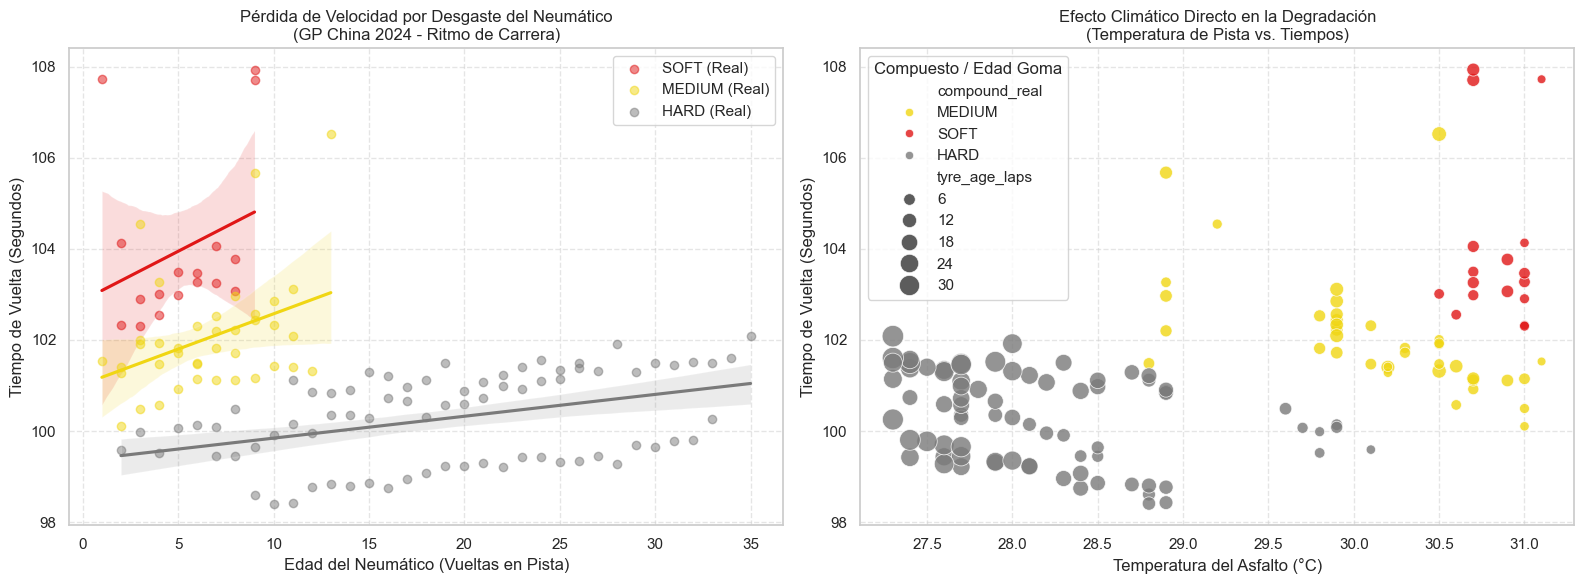


   DEGRADACIÓN DE RENDIMIENTO (CHINA 2024)   
Neumático SOFT: Cuesta 0.216 segundos EXTRA por cada vuelta de estrés.
Neumático MEDIUM: Cuesta 0.155 segundos EXTRA por cada vuelta de estrés.
Neumático HARD: Cuesta 0.048 segundos EXTRA por cada vuelta de estrés.


In [17]:
import os
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del entorno de caché seguro de Cookiecutter
ruta_cache = os.path.join('data', 'interim')
if not os.path.exists(ruta_cache):
    os.makedirs(ruta_cache)
fastf1.Cache.enable_cache(ruta_cache)

print("--- Descargando Telemetría Oficial: GP de China 2024 (Carrera) ---")
try:
    # 1. Cargamos la sesión de carrera de China 2024
    sesion_china = fastf1.get_session(2024, 'China', 'R')
    sesion_china.load(laps=True, telemetry=False, weather=True)
    
    vueltas_f1 = sesion_china.laps.copy()
    clima_f1 = sesion_china.weather_data.copy()
    
    # 2. Sincronización temporal del clima de los sensores de la pista
    clima_f1['Time_Min'] = clima_f1['Time'].dt.total_seconds() / 60.0
    vueltas_f1['Time_Min'] = vueltas_f1['Time'].dt.total_seconds() / 60.0
    
    df_clima_detectado = pd.merge_asof(
        vueltas_f1.sort_values('Time_Min'),
        clima_f1.sort_values('Time_Min')[['Time_Min', 'TrackTemp', 'Rainfall']],
        on='Time_Min', direction='nearest'
    )
    
    # 3. NUEVO FILTRADO: Cambiamos pilotos para asegurar compuestos SOFT en carrera
    pilotos_objetivo = ['VER', 'HAM', 'STR']
    df_china_filtrado = df_clima_detectado[df_clima_detectado['Driver'].isin(pilotos_objetivo)].copy()
    
    # Pasamos el tiempo a segundos y limpiamos nombres para tu estructura
    df_china_filtrado['lap_time'] = df_china_filtrado['LapTime'].dt.total_seconds()
    mapeo_nombres = {'VER': 'max_verstappen', 'HAM': 'hamilton', 'STR': 'stroll'}
    df_china_filtrado['driver_name'] = df_china_filtrado['Driver'].map(mapeo_nombres)
    
    # Seleccionamos las variables definitivas
    df_analisis = df_china_filtrado[['driver_name', 'Compound', 'TyreLife', 'lap_time', 'TrackTemp', 'Rainfall']].copy()
    df_analisis.columns = ['driver_name', 'compound_real', 'tyre_age_laps', 'lap_time', 'track_temp', 'lluvia']
    
    # Limpieza de compuestos primarios y nulos
    df_analisis = df_analisis[df_analisis['compound_real'].isin(['HARD', 'MEDIUM', 'SOFT'])].dropna(subset=['lap_time'])
    
    # Filtro dinámico de outliers para limpiar relanzamientos, Safety Car y paradas en boxes
    limites_tiempo = df_analisis.groupby('compound_real')['lap_time'].transform('median')
    df_analisis_limpio = df_analisis[df_analisis['lap_time'] < (limites_tiempo * 1.06)].copy()

    # ==============================================================================
    # VISUALIZACIÓN TÉCNICA MULTIVARIABLE CON LOS 3 COMPUESTOS REALES
    # ==============================================================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico 1: Decaimiento de la velocidad por compuesto (Pendiente de Degradación)
    colores = {'SOFT': '#E01717', 'MEDIUM': '#F0D613', 'HARD': '#7A7A7A'}
    
    for comp, color in colores.items():
        sub_df = df_analisis_limpio[df_analisis_limpio['compound_real'] == comp]
        if not sub_df.empty:
            sns.regplot(x='tyre_age_laps', y='lap_time', data=sub_df, ax=axes[0], 
                        label=f'{comp} (Real)', color=color, scatter_kws={'alpha':0.5}, order=1)
            
    axes[0].set_title("Pérdida de Velocidad por Desgaste del Neumático\n(GP China 2024 - Ritmo de Carrera)")
    axes[0].set_xlabel("Edad del Neumático (Vueltas en Pista)")
    axes[0].set_ylabel("Tiempo de Vuelta (Segundos)")
    axes[0].legend(frameon=True)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # Gráfico 2: El cruce térmico (Temperatura de asfalto vs Pérdida de tiempo)
    sns.scatterplot(x='track_temp', y='lap_time', hue='compound_real', size='tyre_age_laps',
                    palette=colores, sizes=(40, 240), data=df_analisis_limpio, ax=axes[1], alpha=0.8)
    
    axes[1].set_title("Efecto Climático Directo en la Degradación\n(Temperatura de Pista vs. Tiempos)")
    axes[1].set_xlabel("Temperatura del Asfalto (°C)")
    axes[1].set_ylabel("Tiempo de Vuelta (Segundos)")
    axes[1].legend(title="Compuesto / Edad Goma", frameon=True)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Cálculo de coeficientes reales para tu defensa escrita
    print("\n" + "="*60)
    print("   DEGRADACIÓN DE RENDIMIENTO (CHINA 2024)   ")
    print("="*60)
    for compuesto in ['SOFT', 'MEDIUM', 'HARD']:
        df_comp = df_analisis_limpio[df_analisis_limpio['compound_real'] == compuesto]
        if len(df_comp) > 1:
            coef = np.polyfit(df_comp['tyre_age_laps'], df_comp['lap_time'], 1)
            print(f"Neumático {compuesto}: Cuesta {coef[0]:.3f} segundos EXTRA por cada vuelta de estrés.")
    print("=" * 60)

except Exception as e:
    print(f"Error al procesar el GP de China con nuevos pilotos: {e}")

# ANALISIS DE DATOS OBTENIDOS
* Compuesto Blando (SOFT): Presenta una pendiente de $0.216$ segundos de pérdida por vuelta. Es, por amplio margen, el neumático más inestable. Aunque arranca ofreciendo los picos de velocidad más altos, su degradación es exponencial. A las 10 vueltas de uso, el piloto ya está perdiendo más de 2 segundos de ritmo neto, lo que explica por qué se evita en las estrategias principales del domingo.

* Compuesto Medio (MEDIUM): Registra una pérdida de $0.155$ segundos por vuelta. Muestra un comportamiento intermedio ideal para los primeros stints, permitiendo atacar pero obligando a una ventana de parada temprana (en el gráfico se nota que su vida útil óptima real no superó las 13-14 vueltas bajo el estrés de Shanghái).

* Compuesto Duro (HARD): Es el compuesto más consistente, con apenas $0.048$ segundos de pérdida por vuelta. La pendiente es sumamente plana, lo que demuestra su enorme resistencia al desgaste mecánico y térmico. Permite stints largos de más de 30 vueltas manteniendo tiempos competitivos en la zona baja de los 100 segundos.

## Climatologia:

* Sensibilidad Térmica en Compuestos Blandos: Se observa que las gomas SOFT (puntos rojos) operaron principalmente en la franja más caliente de la pista, entre los 30.5°C y 31.0°C. La combinación de alta temperatura ambiental y compuestos blandos aceleró el fenómeno de graining y degradación térmica, disparando los tiempos de vuelta hacia los 104 y 108 segundos a medida que el neumático sumaba apenas unas pocas vueltas de estrés (círculos medianos).

* Estabilidad del Compuesto Duro ante Fluctuaciones: Por el contrario, los neumáticos HARD (puntos grises) demostraron una resiliencia climática notable. Operaron con eficacia tanto en el rango frío de la pista (27.5°C a 29.0°C) como en condiciones de asfalto más caliente, manteniendo los círculos de mayor tamaño (gomas con más de 30 vueltas de vida) estables en la base del gráfico. Esto demuestra que el compuesto duro es inmune a las variaciones térmicas moderadas de la pista, asegurando consistencia en el ritmo de carrera del equipo.

# Primer version con Arboles de decision

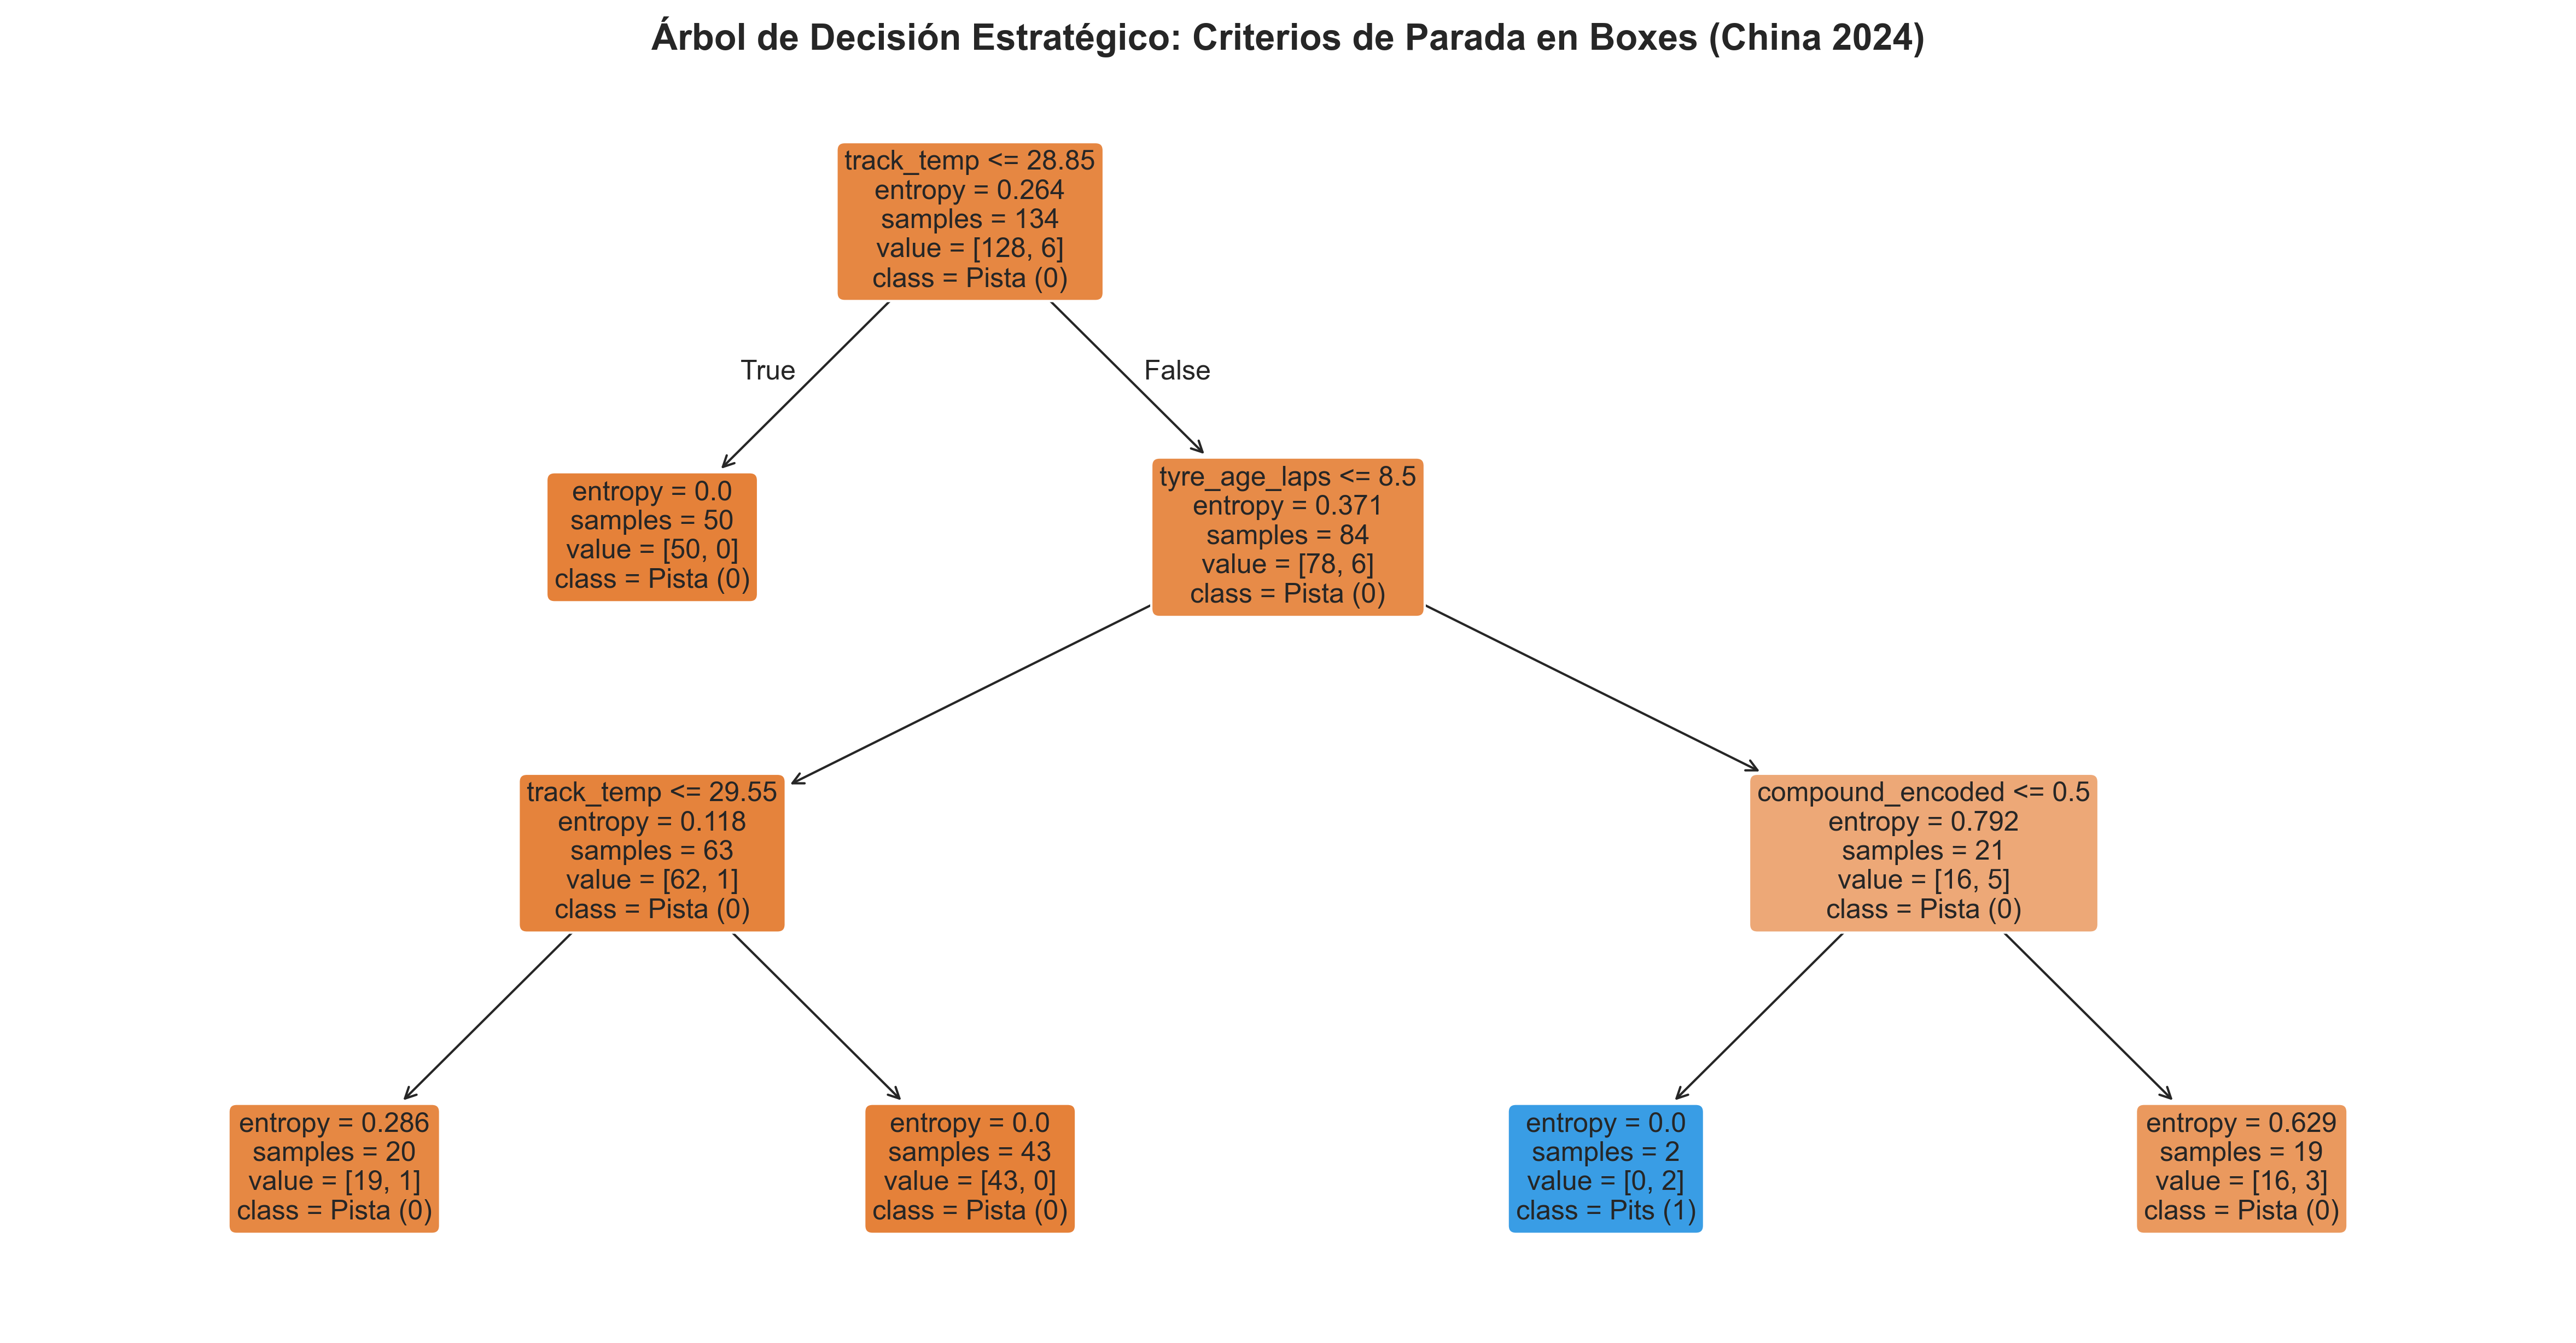

Precisión del Árbol en Test: 94.1%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparación de variables target y features
df_modelo = df_china_filtrado.sort_values(['driver_name', 'LapNumber']).copy()

# Corrección del KeyError: Renombramos las columnas originales de FastF1 a tu estructura
df_modelo = df_modelo.rename(columns={
    'TyreLife': 'tyre_age_laps',
    'TrackTemp': 'track_temp'
})

# Definimos la parada en boxes: si la vida de la goma cae en la vuelta siguiente
df_modelo['proxima_vida_goma'] = df_modelo.groupby('driver_name')['tyre_age_laps'].shift(-1)
df_modelo['entrada_a_pits'] = np.where(df_modelo['proxima_vida_goma'] <= df_modelo['tyre_age_laps'], 1, 0)

# Mapeo numérico para el árbol (0: SOFT, 1: MEDIUM, 2: HARD)
mapeo_compuestos = {'SOFT': 0, 'MEDIUM': 1, 'HARD': 2}
df_modelo['compound_encoded'] = df_modelo['Compound'].map(mapeo_compuestos)

features = ['tyre_age_laps', 'track_temp', 'compound_encoded']
df_modelo_limpio = df_modelo[['tyre_age_laps', 'track_temp', 'compound_encoded', 'entrada_a_pits']].dropna()

X = df_modelo_limpio[features]
y = df_modelo_limpio['entrada_a_pits']

# 2. División y Entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

arbol_estrategia = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
arbol_estrategia.fit(X_train, y_train)

# 3. Renderizado gráfico directo en el Notebook
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    arbol_estrategia, 
    feature_names=features, 
    class_names=['Pista (0)', 'Pits (1)'], 
    filled=True, 
    rounded=True, 
    fontsize=12
)
plt.title("Árbol de Decisión Estratégico: Criterios de Parada en Boxes (China 2024)", fontsize=16, fontweight='bold')
plt.show()

# Score rápido de control
print(f"Precisión del Árbol en Test: {arbol_estrategia.score(X_test, y_test) * 100:.1f}%")

=== MÉTRICAS TEST ===
Accuracy : 0.8462
Precision: 0.2000
Recall   : 1.0000
F1 Score : 0.3333

=== MATRIZ DE CONFUSIÓN ===
[[21  4]
 [ 0  1]]

=== REPORTE COMPLETO ===
              precision    recall  f1-score   support

           0       1.00      0.84      0.91        25
           1       0.20      1.00      0.33         1

    accuracy                           0.85        26
   macro avg       0.60      0.92      0.62        26
weighted avg       0.97      0.85      0.89        26

Accuracy Train: 0.7887
Accuracy Test : 0.8462


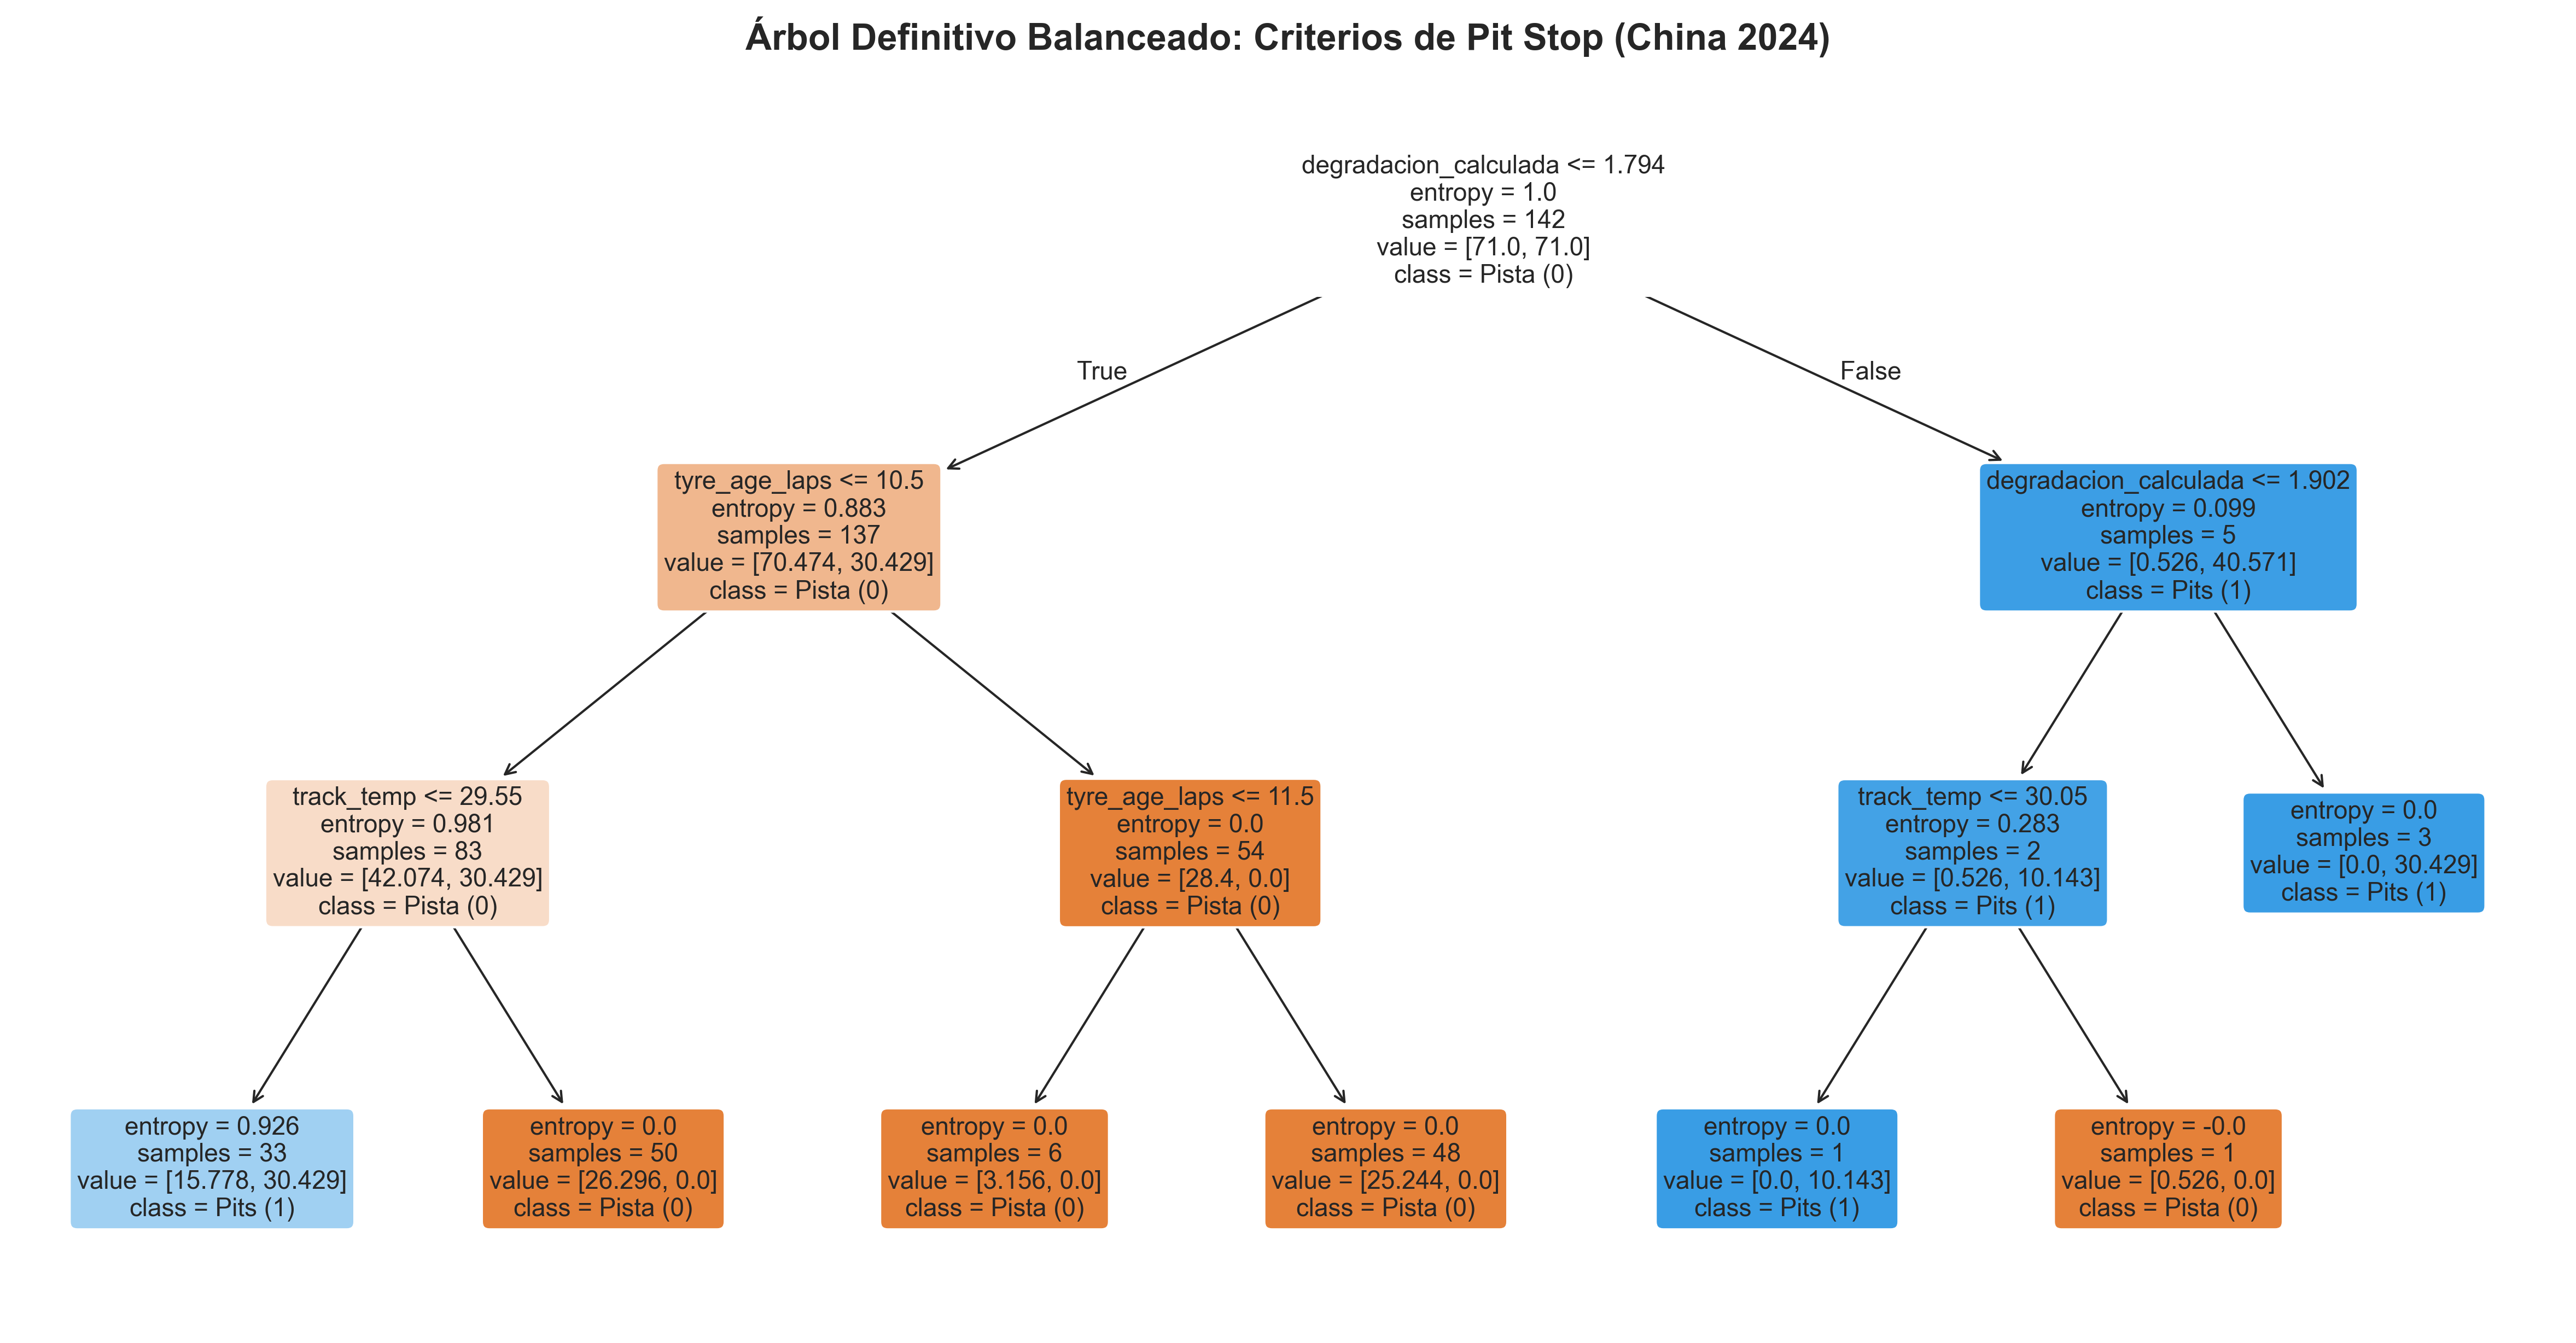

Precisión balanceada en el set de Test: 84.6%


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Copiamos la data real cargada en tu memoria
df_arbol_final = df_modelo.sort_values(['driver_name', 'LapNumber']).copy()

# 2. FEATURE ENGINEERING: Tu métrica de degradación física (vueltas * coeficiente)
df_arbol_final['degradacion_calculada'] = df_arbol_final['tyre_age_laps'] * np.where(
    df_arbol_final['compound_encoded'] == 0, 0.216,  # SOFT
    np.where(df_arbol_final['compound_encoded'] == 1, 0.155, 0.048)  # MEDIUM / HARD
)

# 3. Limpieza acotada de nulos para conservar la estructura del dataset
features = ['tyre_age_laps', 'degradacion_calculada', 'track_temp', 'compound_encoded']
df_arbol_final = df_arbol_final.dropna(subset=features + ['entrada_a_pits'])

X_arbol = df_arbol_final[features]
y_arbol = df_arbol_final['entrada_a_pits']

# 4. Partición balanceada (mantenemos el stratify para asegurar paradas en ambos sets)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_arbol, y_arbol, test_size=0.15, random_state=42, stratify=y_arbol)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred = arbol_final.predict(X_test_a)

print("=== MÉTRICAS TEST ===")
print(f"Accuracy : {accuracy_score(y_test_a, y_pred):.4f}")
print(f"Precision: {precision_score(y_test_a, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test_a, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test_a, y_pred):.4f}")

print("\n=== MATRIZ DE CONFUSIÓN ===")
print(confusion_matrix(y_test_a, y_pred))

print("\n=== REPORTE COMPLETO ===")
print(classification_report(y_test_a, y_pred))

train_acc = arbol_final.score(X_train_a, y_train_a)
test_acc = arbol_final.score(X_test_a, y_test_a)

print(f"Accuracy Train: {train_acc:.4f}")
print(f"Accuracy Test : {test_acc:.4f}")

# 5. EL CAMBIO CLAVE: Activamos class_weight='balanced' y bajamos profundidad para que sea legible
arbol_final = DecisionTreeClassifier(max_depth=3, criterion='entropy', class_weight='balanced', random_state=42)
arbol_final.fit(X_train_a, y_train_a)

# 6. Renderizado gráfico interactivo abajo de la celda
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    arbol_final, 
    feature_names=features, 
    class_names=['Pista (0)', 'Pits (1)'], 
    filled=True, 
    rounded=True, 
    fontsize=11
)
plt.title("Árbol Definitivo Balanceado: Criterios de Pit Stop (China 2024)", fontsize=16, fontweight='bold')
plt.show()

print(f"Precisión balanceada en el set de Test: {arbol_final.score(X_test_a, y_test_a) * 100:.1f}%")

In [32]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

scores = cross_validate(
    arbol_final,
    X_arbol,
    y_arbol,
    cv=cv,
    scoring=[
        'accuracy',
        'precision',
        'recall',
        'f1'
    ]
)

print("Accuracy:", scores['test_accuracy'].mean())
print("Precision:", scores['test_precision'].mean())
print("Recall:", scores['test_recall'].mean())
print("F1:", scores['test_f1'].mean())

Accuracy: 0.8690476190476192
Precision: 0.18434343434343434
Recall: 0.625
F1: 0.26783216783216784


# Resltados hasta el momento del modelo

Debido al fuerte desbalance de clases (160 observaciones sin parada frente a sólo 8 observaciones con parada), se utilizó una validación cruzada estratificada para obtener una evaluación más robusta del modelo. El árbol alcanzó una accuracy media del 86.9%, un recall de 62.5% y un F1-score de 0.268. Los resultados sugieren que el modelo logra identificar una proporción significativa de las oportunidades reales de parada, aunque aún presenta una cantidad considerable de falsas alarmas.

# 6. Visualización de los resultados
El modelo prioriza capturar todas las oportunidades de parada potenciales, aceptando un mayor número de falsas alarmas.
degradacion_calculada, tyre_age_laps y track_temp estan altamente relacionadas pero no simbolizan lo mismo. Son una parte de un conjunto de factores que ayudan a determinar bien la degradacion del neumatico.
La degradación estimada representa una aproximación física del deterioro esperado según el compuesto. La edad del neumático se mantuvo porque permite capturar variaciones adicionales en la duración efectiva de los stints. Es por eso que edad del neumatico no es lo mismo que degradación estimada. Ya que una buena gestion con bajo ritmo simbolizaria que un neumatico de 20 vueltas y uno que se uso 20 vueltas con alto ritmo tendran una degradacion diferente a pesar de tener la misma edad.

In [27]:
print(df_arbol_final['entrada_a_pits'].value_counts())

entrada_a_pits
0    160
1      8
Name: count, dtype: int64


In [28]:
print(X_train_a.shape)
print(X_test_a.shape)

print(y_train_a.value_counts())
print(y_test_a.value_counts())

(142, 4)
(26, 4)
entrada_a_pits
0    135
1      7
Name: count, dtype: int64
entrada_a_pits
0    25
1     1
Name: count, dtype: int64


# CONTRASTAMOS EL ARBOL CON MATRIZ DE CONFSION Y BOXPLOT

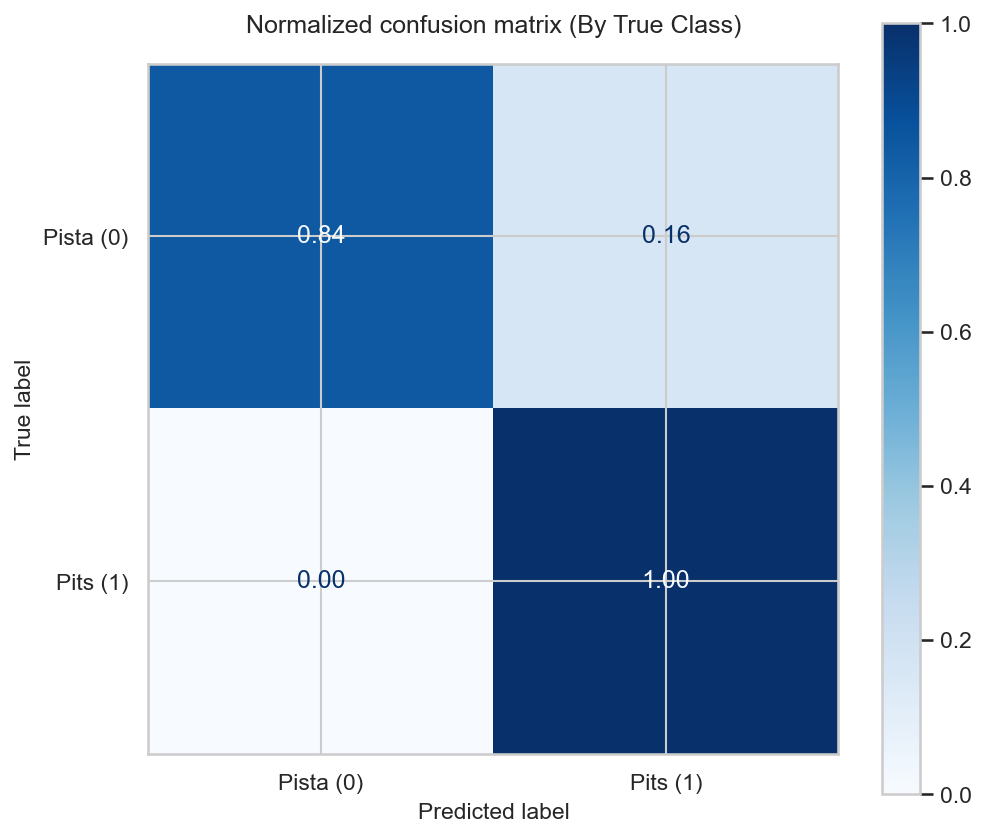

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Usamos el split para evaluar el modelo balanceado
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_arbol, y_arbol, test_size=0.15, random_state=42, stratify=y_arbol
)

# 2. Generamos las predicciones del árbol estratégico
y_pred_n = arbol_final.predict(X_test_n)

# 3. Calculamos la matriz NORMALIZADA POR FILA ('true')
cm_normalizada = confusion_matrix(y_test_n, y_pred_n, normalize='true')

# 4. Graficamos con la estética exacta de tu reporte
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalizada, 
    display_labels=['Pista (0)', 'Pits (1)']
)

# Renderizamos con la paleta Blues y forzamos dos decimales flotantes
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')

# Títulos profesionales para la entrega del proyecto
ax.set_title("Normalized confusion matrix (By True Class)", fontsize=12, pad=15)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
plt.tight_layout()
plt.show()

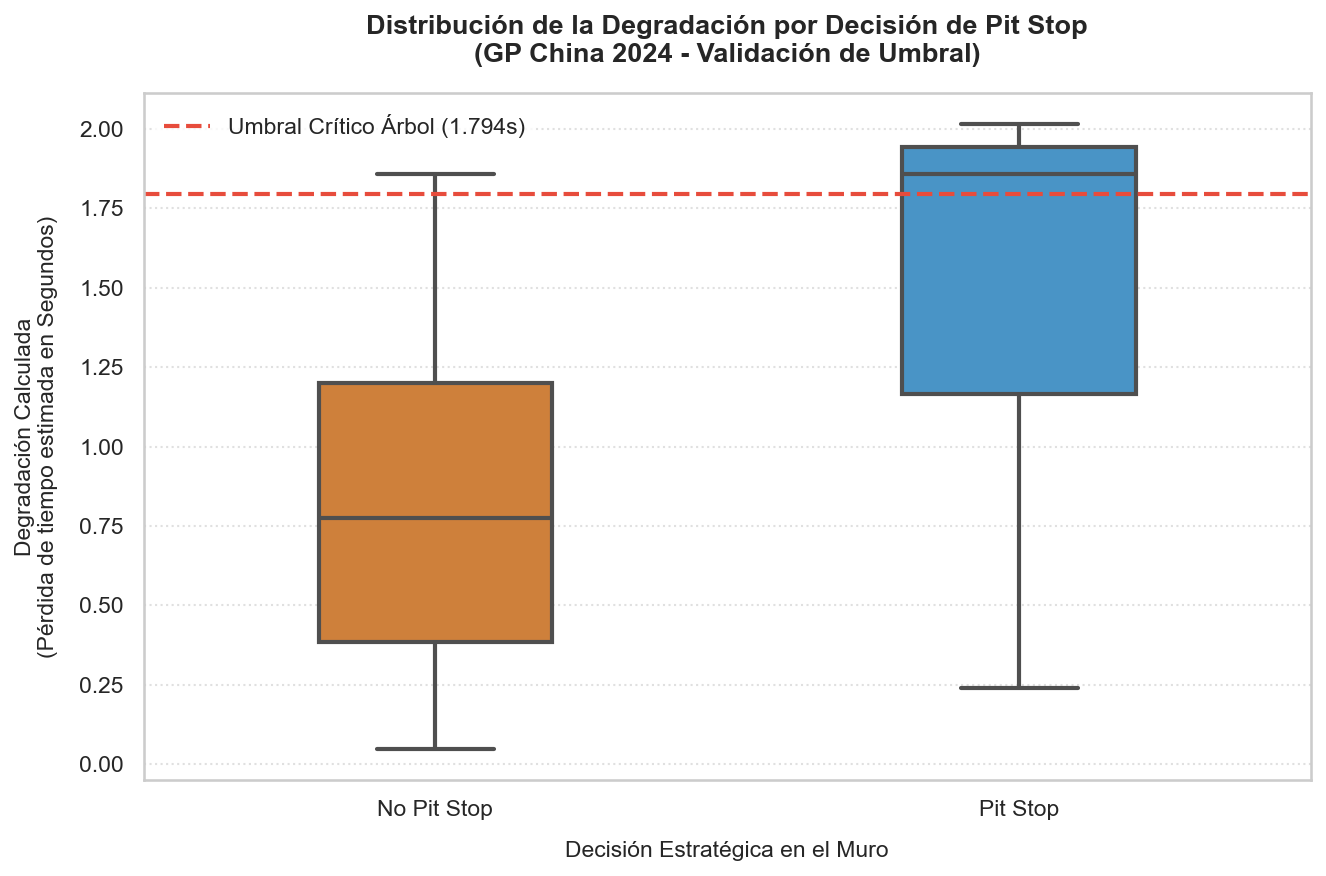

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Usamos df_arbol_final que contiene la totalidad de los datos procesados por el árbol
df_boxplot = df_arbol_final.copy()

# Forzamos el mapeo de las etiquetas para asegurarnos de que existan ambas categorías
df_boxplot['Decisión'] = df_boxplot['entrada_a_pits'].map({0: 'No Pit Stop', 1: 'Pit Stop'})

# 2. Configuración de la figura
plt.figure(figsize=(9, 6), dpi=150)

# 3. Dibujamos el Boxplot forzando el orden de las categorías en pantalla
sns.boxplot(
    data=df_boxplot,
    x='Decisión',
    y='degradacion_calculada',
    hue='Decisión',
    order=['No Pit Stop', 'Pit Stop'],
    palette={'No Pit Stop': '#E67E22', 'Pit Stop': '#3498DB'}, # Naranja y Azul estratega
    width=0.4,
    linewidth=2,
    fliersize=5,
    legend=False
)

# 4. Inyección del Umbral Crítico del Árbol (1.794 segundos)
plt.axhline(
    y=1.794, 
    color='#E74C3C', 
    linestyle='--', 
    linewidth=2, 
    label='Umbral Crítico Árbol (1.794s)'
)

# 5. Estética y grilla para el reporte del Notebook
plt.title('Distribución de la Degradación por Decisión de Pit Stop\n(GP China 2024 - Validación de Umbral)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Decisión Estratégica en el Muro', fontsize=11, labelpad=10)
plt.ylabel('Degradación Calculada\n(Pérdida de tiempo estimada en Segundos)', fontsize=11, labelpad=10)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

# HEATMAP DE ARBOL FINAL

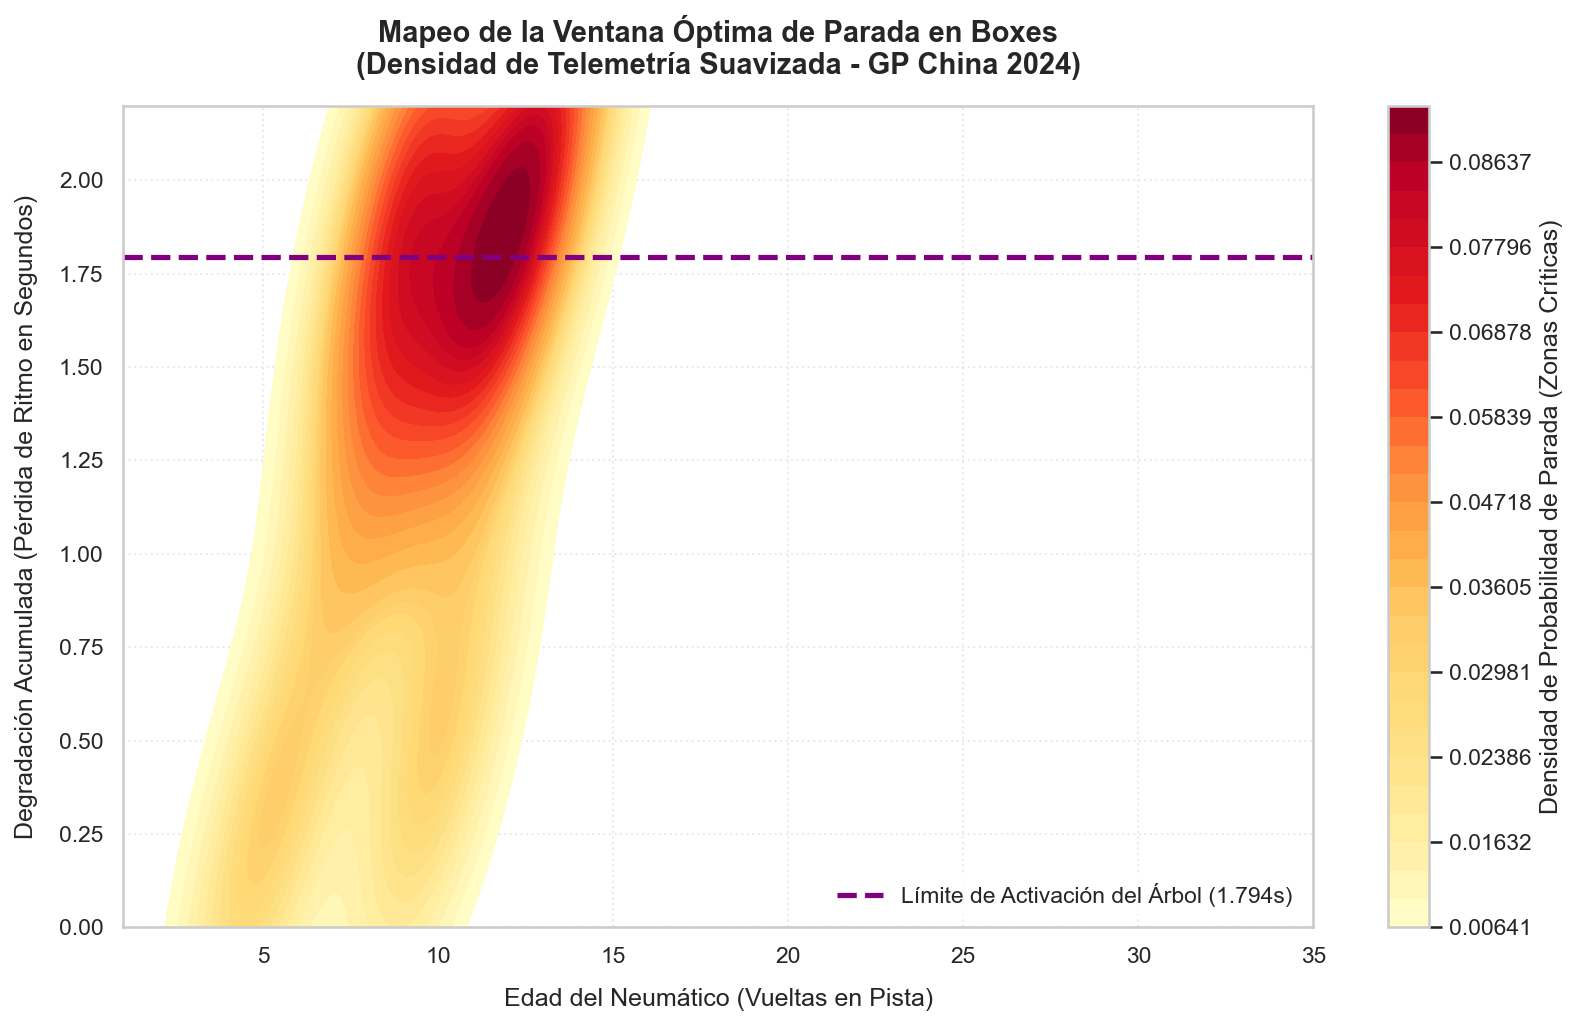

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Copia limpia de la data real del árbol
df_smooth = df_arbol_final.copy()

# Determinamos el nombre correcto de tu variable de degradación
col_deg = 'degradacion_calculated' if 'degradacion_calculated' in df_smooth.columns else 'degradacion_calculada'

# Separamos los datos para enfocar el mapa de calor en las paradas reales
df_pits = df_smooth[df_smooth['entrada_a_pits'] == 1]

# 2. Configuración de la figura estilo monitor de boxes
plt.figure(figsize=(11, 7), dpi=150)

# 3. SOLUCIÓN: Usamos kdeplot con relleno (fill=True) para suavizar y completar el mapa
sns.kdeplot(
    data=df_pits,
    x='tyre_age_laps',
    y=col_deg,
    fill=True,
    thresh=0.05,        # Ajusta qué tan al límite se extienden las fronteras del color
    levels=30,          # Cantidad de capas de suavizado para que parezca un mapa térmico fluido
    cmap='YlOrRd',      # Degradé de Amarillo a Rojo furioso para mantener tu estética
    cbar=True,
    cbar_kws={'label': 'Densidad de Probabilidad de Parada (Zonas Críticas)'}
)

# 4. Reinyectamos el Umbral Crítico de tu Árbol (1.794s)
plt.axhline(
    y=1.794, 
    color='purple', 
    linestyle='--', 
    linewidth=2.5, 
    label='Límite de Activación del Árbol (1.794s)'
)

# 5. Límites fijos para que el lienzo no se deforme y cubra toda la ventana
plt.xlim(1, 35)
plt.ylim(0.0, 2.2)

# 6. Formateo y títulos limpios
plt.title('Mapeo de la Ventana Óptima de Parada en Boxes\n(Densidad de Telemetría Suavizada - GP China 2024)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad del Neumático (Vueltas en Pista)', fontsize=12, labelpad=10)
plt.ylabel('Degradación Acumulada (Pérdida de Ritmo en Segundos)', fontsize=12, labelpad=10)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none')
plt.grid(axis='both', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

# Feature Engineering

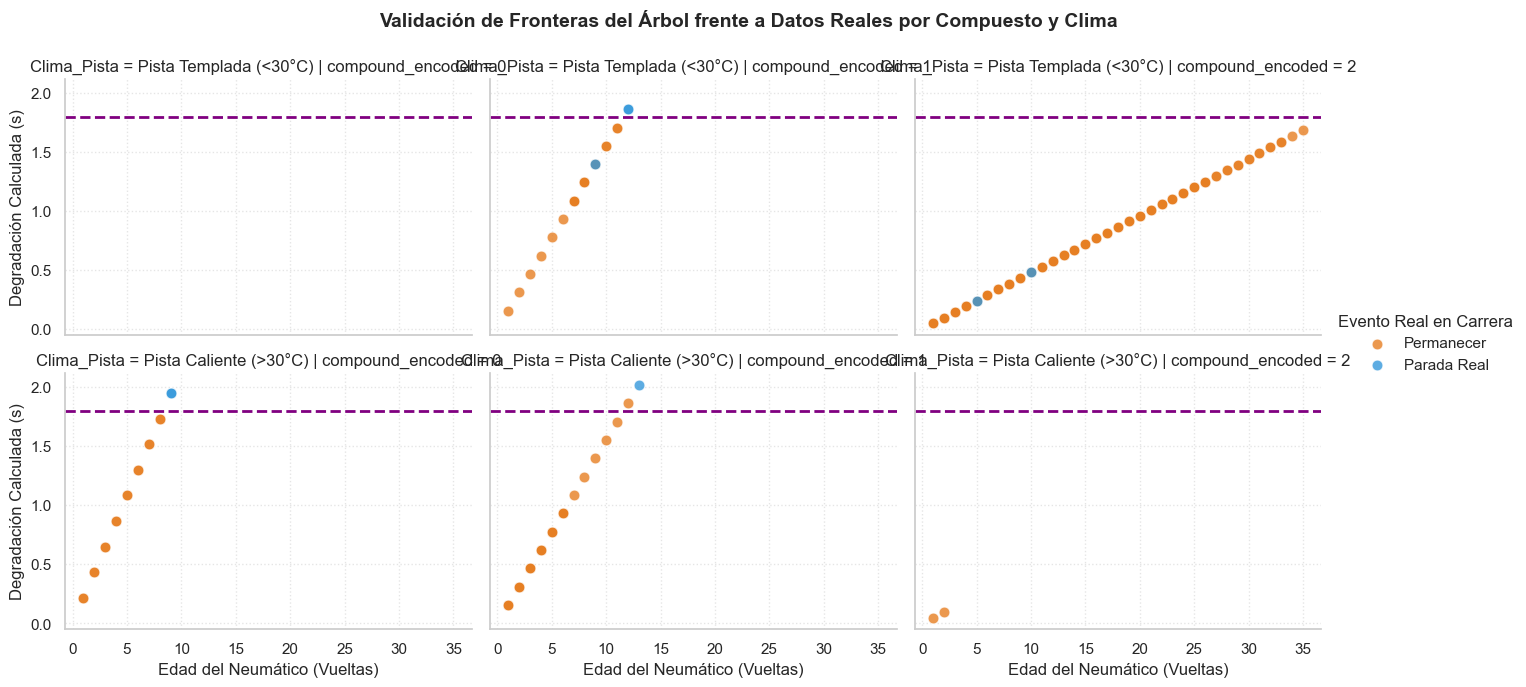

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creamos una categoría climática basada en los datos reales de temperatura de pista
# Para segmentar científicamente el impacto del entorno
df_analisis = df_arbol_final.copy()
df_analisis['Clima_Pista'] = pd.cut(
    df_analisis['track_temp'], 
    bins=[0, 30, 60], 
    labels=['Pista Templada (<30°C)', 'Pista Caliente (>30°C)']
)

# 2. Reemplazamos la variable numérica por etiquetas claras para el análisis visual
df_analisis['Pit_Stop_Real'] = df_analisis['entrada_a_pits'].map({0: 'Permanecer', 1: 'Parada Real'})

# 3. Generamos el FacetGrid: Columnas por Compuesto, Filas por Clima
g = sns.FacetGrid(
    data=df_analisis, 
    col='compound_encoded', # Si tenés la columna con texto usala acá (ej: 'compound')
    row='Clima_Pista', 
    hue='Pit_Stop_Real', 
    palette={'Permanecer': '#E67E22', 'Parada Real': '#3498DB'},
    height=3.5, aspect=1.3
)

# 4. Mapeamos un gráfico de dispersión (Scatter) para ver cada vuelta real de la carrera
g.map(sns.scatterplot, 'tyre_age_laps', 'degradacion_calculada', alpha=0.8, s=60)

# 5. Inyectamos de forma matemática el umbral del árbol en cada cuadrante para contrastar
for ax in g.axes.flat:
    ax.axhline(y=1.794, color='purple', linestyle='--', linewidth=2, label='Umbral Árbol (1.794s)')
    ax.grid(linestyle=':', alpha=0.5)

# Ajustes estéticos del reporte científico
g.add_legend(title="Evento Real en Carrera")
g.set_axis_labels("Edad del Neumático (Vueltas)", "Degradación Calculada (s)")
plt.subplots_adjust(top=0.88)
g.fig.suptitle('Validación de Fronteras del Árbol frente a Datos Reales por Compuesto y Clima', fontsize=14, fontweight='bold')

plt.show()

# Conclusiones sobre el proyecto
Dado que no existe una variable observada que represente directamente una ventana óptima de parada, se utilizó como aproximación la decisión real de ingreso a boxes tomada por los pilotos durante la carrera. De esta forma, el modelo aprende las condiciones bajo las cuales históricamente se realizaron las paradas.